<a href="https://colab.research.google.com/github/yitingchen00/Data_analysis_related_projects/blob/main/term_project_0606.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 任務清單ver5

1.   環境初始化與套件載入
2.   讀取 2020-2022 年的銷售與通話歷史資料，並進行格式統一。
3.   依據歷史销售資料，計算每個「品號」的客戶重購時間間隔。全域中位數為 172 天。
4.   構建每位客戶 24 個月的動態行為特徵矩陣。
在每個月份區間內，動態滾動計算 7 個關鍵特徵：$R$（距上次購買天數）、$F$（當月購買次數）、$M$（當月金額）、$C$（當月通話次數）、個人平均回購週期、週期偏差（超期或提前天數）以及逾期倍率。

5.   載入 2022 年的真實客戶狀態標籤，並與特徵矩陣的會員順序完全對齊。
6.   將文字標籤轉換為模型可接收的類別數字。
7.   對特徵進行對數轉換與縮放，並劃分訓練與驗證集。Class Weight： 計算 balanced 類別權重，以解決 Loyal 客群樣本過少的不平衡問題。
8.   建構並訓練時序深度學習模型（LSTM）。

9.  引入卷積神經網路（CNN）作為另一個時序特徵提取模型。
10. 建立機器學習模型並比較Macro F1-score
11.  特徵重要性視覺化
13.  利用傳統機器模型與深度學習模型預測顧客類別

第一階段

In [3]:
#儲存格1
import pandas as pd
import numpy as np
from datetime import datetime

# 資料處理
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score


# 深度學習
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Attention,
                                    GlobalAveragePooling1D,
                                     LayerNormalization, Dropout)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# 視覺化
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#儲存格2
# --- 載入並合併銷售資料 (2020-2022) ---
# 這裡根據你上傳的檔案名稱進行讀取 (假設已轉成 CSV 或直接讀 Excel)
sales_2020 = pd.read_excel('transaction1.xlsx')
sales_2021 = pd.read_excel('transaction2.xlsx')
sales_2022 = pd.read_excel('transaction3.xlsx')

df_sales = pd.concat([sales_2020, sales_2021, sales_2022], ignore_index=True)

# --- 載入並合併通話紀錄 (2020-2022) ---
calls_2020 = pd.read_excel('CallRecords1.xlsx')
calls_2021 = pd.read_excel('CallRecords2.xlsx')
calls_2022 = pd.read_excel('CallRecords3.xlsx')

df_calls = pd.concat([calls_2020, calls_2021, calls_2022], ignore_index=True)

# --- 會員編號規格化函數 ---
def process_member_id(x):
    try:
        # 移除空格並確保是字串
        sid = str(x).strip().split('.')[0] # 處理像 "123.0" 的情況
        if not sid or sid == 'nan': return None

        # 你的 add_prefix 邏輯
        if sid.startswith('9'):
            return 'C0' + sid
        else:
            return 'C' + sid
    except:
        return None

# 套用編號轉換
df_sales['新會員編號'] = df_sales['會員編號'].apply(process_member_id)
df_calls['新會員編號'] = df_calls['會員編號'].apply(process_member_id)

# --- 日期格式統一 ---
df_sales['訂單日期'] = pd.to_datetime(df_sales['訂單日期'])
df_calls['通話日期'] = pd.to_datetime(df_calls['Call In/Out 日期'])

# --- 清理數值 ---
df_sales['金額'] = pd.to_numeric(df_sales['金額'], errors='coerce').fillna(0)
df_calls['通話時間(秒)'] = pd.to_numeric(df_calls['通話時間(秒)'], errors='coerce').fillna(0)

print("資料合併與規格化完成！")
print(f"銷售紀錄：{df_sales.shape[0]} 筆，通話紀錄：{df_calls.shape[0]} 筆")

資料合併與規格化完成！
銷售紀錄：39211 筆，通話紀錄：125765 筆


In [5]:
#儲存格3
def compute_product_cycles(df_sales):
    df = df_sales[['新會員編號', '品號', '訂單日期']].dropna().copy()
    df = df.sort_values(['新會員編號', '品號', '訂單日期'])

    # 同一顧客同一品號的相鄰購買間隔
    df['prev_date'] = df.groupby(['新會員編號', '品號'])['訂單日期'].shift(1)
    df['interval']  = (df['訂單日期'] - df['prev_date']).dt.days
    df = df.dropna(subset=['interval'])
    df = df[df['interval'] > 0]   # 排除同天重複筆

    product_cycle  = df.groupby('品號')['interval'].median().to_dict()
    global_default = df['interval'].median()

    print(f"品號回購週期計算完成：{len(product_cycle)} 個品號，全域中位數 = {global_default:.0f} 天")
    return product_cycle, global_default

product_cycle_map, GLOBAL_DEFAULT_CYCLE = compute_product_cycles(df_sales)

品號回購週期計算完成：66 個品號，全域中位數 = 172 天


In [7]:
#儲存格4
# 主函數：產生每位顧客的月度序列特徵（7 維）
# 特徵順序：[R, F, M, C, personal_avg_cycle, cycle_deviation, overdue_ratio]
def generate_dynamic_rfm_sequences(df_sales, df_calls,
                                   start_ym='2020-01', end_ym='2021-12'):
    all_months  = pd.period_range(start=start_ym, end=end_ym, freq='M')
    start_year  = int(start_ym.split('-')[0])
    end_year    = int(end_ym.split('-')[0])

    target_customers = df_sales[
        df_sales['訂單日期'].dt.year.isin(range(start_year, end_year + 1))
    ]['新會員編號'].unique()

    sales_grouped = df_sales.groupby('新會員編號')
    calls_grouped = df_calls.groupby('新會員編號')

    X_list, final_uids = [], []

    for uid in target_customers:
        user_sales = (sales_grouped.get_group(uid).sort_values('訂單日期')
                      if uid in sales_grouped.groups else pd.DataFrame())
        user_calls = (calls_grouped.get_group(uid)
                      if uid in calls_grouped.groups else pd.DataFrame())

        user_sequence    = []
        last_purchase    = None
        purchase_intervals = []   # 累積個人回購間隔

        for month in all_months:
            m_start = month.to_timestamp()
            m_end   = month.to_timestamp('M')

            month_sales = (user_sales[
                (user_sales['訂單日期'] >= m_start) &
                (user_sales['訂單日期'] <= m_end)
            ] if not user_sales.empty else pd.DataFrame())

            month_calls = (user_calls[
                (user_calls['通話日期'] >= m_start) &   # ← 確認欄位名稱
                (user_calls['通話日期'] <= m_end)
            ] if not user_calls.empty else pd.DataFrame())

            # ── 原本 4 個特徵 ──
            R = (m_end - last_purchase).days if last_purchase else 365
            F = len(month_sales)
            M = month_sales['金額'].sum() if not month_sales.empty else 0
            C = len(month_calls)

            # ── 更新個人購買間隔 ──
            if not month_sales.empty and last_purchase is not None:
                gap = (month_sales['訂單日期'].min() - last_purchase).days
                if gap > 0:
                    purchase_intervals.append(gap)

            # ── 特徵 5：個人平均回購週期 ──
            if purchase_intervals:
                personal_avg_cycle = np.mean(purchase_intervals)
            elif not month_sales.empty:
                # 用這個月買的品號推算
                items = month_sales['品號'].unique()
                personal_avg_cycle = np.mean([
                    product_cycle_map.get(i, GLOBAL_DEFAULT_CYCLE) for i in items
                ])
            else:
                personal_avg_cycle = GLOBAL_DEFAULT_CYCLE

            # ── 特徵 6：偏差（正 = 超期未購，負 = 提前回購）──
            cycle_deviation = R - personal_avg_cycle

            # ── 特徵 7：逾期倍率（>1 代表已超過一個週期）──
            overdue_ratio = R / personal_avg_cycle if personal_avg_cycle > 0 else 1.0

            # ── 特徵 8：逾期倍率（>1 代表已超過一個週期）──



            user_sequence.append([R, F, M, C,
                                   personal_avg_cycle,
                                   cycle_deviation,
                                   overdue_ratio])

            if not month_sales.empty:
                last_purchase = month_sales['訂單日期'].max()

        if len(user_sequence) == len(all_months):
            X_list.append(user_sequence)
            final_uids.append(uid)

    X = np.array(X_list, dtype=np.float32)
    print(f"特徵矩陣：{X.shape}  →  應為 (N, {len(all_months)}, 7)")
    return X, final_uids


X_train, customer_ids = generate_dynamic_rfm_sequences(
    df_sales, df_calls, '2020-01', '2021-12')

特徵矩陣：(1839, 24, 7)  →  應為 (N, 24, 7)


In [9]:
#儲存格5
# 標籤載入與精確對齊

# 1. 載入標籤原始資料
df_label_raw = pd.read_excel('label.xlsx')

# 2. 直接呼叫已定義過的函數
df_label_raw['新會員編號'] = df_label_raw['會員編號'].apply(process_member_id)

# 3. 建立對應字典 (新會員編號 -> label)
# 加上 drop_duplicates 確保一個會員只有一個標籤，避免對齊出錯
label_map = df_label_raw.drop_duplicates('新會員編號').set_index('新會員編號')['label'].to_dict()

# 4. 根據 X_train 產出的 customer_ids 順序，精確對齊 y 標籤
# 使用列表推導式提取標籤，若找不到該會員，預設給予 0 (或你可以根據需求調整)
y_train_raw = np.array([label_map.get(uid, 0) for uid in customer_ids])

# --- 檢查對齊結果 ---
print(f"特徵樣本數 (X): {len(customer_ids)}")
print(f"標籤樣本數 (y): {len(y_train_raw)}")

# 檢查是否有會員在標籤檔中找不到
missing_count = sum(1 for uid in customer_ids if uid not in label_map)
if missing_count > 0:
    print(f"⚠️ 警告：有 {missing_count} 位顧客在標籤檔中找不到對應標籤，已預設補 0")
else:
    print("✅ 所有顧客標籤皆已成功對齊！")

# 顯示標籤分佈
unique, counts = np.unique(y_train_raw, return_counts=True)
print("標籤分佈情形：", dict(zip(unique, counts)))

特徵樣本數 (X): 1839
標籤樣本數 (y): 1839
✅ 所有顧客標籤皆已成功對齊！
標籤分佈情形： {np.str_('churn'): np.int64(944), np.str_('loyal'): np.int64(315), np.str_('partial churn'): np.int64(580)}


In [10]:
#儲存格6
# 標籤數值化 (Label Encoding)
# 將文字標籤轉換為數字，定義順序建議：churn(0), partial churn(1), loyal(2)
label_mapping = {'churn': 0, 'partial churn': 1, 'loyal': 2}
y_numeric = np.array([label_mapping[label] for label in y_train_raw])

In [11]:
#儲存格7
# 修改特徵處理邏輯
def preprocess_X(X):
    # 對金額(M)和逾期倍率(最後一維)取對數，減少極端值影響
    # X 形狀為 (N, 24, 7)，M 在索引 2, overdue_ratio 在索引 6
    X_copy = X.copy()
    X_copy[:, :, 2] = np.log1p(X_copy[:, :, 2])
    X_copy[:, :, 6] = np.log1p(X_copy[:, :, 6])
    return X_copy

X_train_pre = preprocess_X(X_train)

# 直接切分，不使用 SMOTE
X_tr_raw, X_val_raw, y_tr_int, y_val_int = train_test_split(
    X_train_pre, y_numeric,
    test_size=0.2, random_state=42, stratify=y_numeric
)

# 標準化
N_tr, STEPS, FEATS = X_tr_raw.shape
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_raw.reshape(-1, FEATS)).reshape(-1, STEPS, FEATS)
X_val_scaled = scaler.transform(X_val_raw.reshape(-1, FEATS)).reshape(-1, STEPS, FEATS)

# 計算類別權重 (解決不平衡問題)
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_tr_int), y=y_tr_int)
class_weight_dict = dict(enumerate(weights))

y_tr_oh = to_categorical(y_tr_int, 3)
y_val_oh = to_categorical(y_val_int, 3)

========== 開始訓練 LSTM 模型 ==========
Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.3868 - loss: 1.3591 - val_accuracy: 0.4239 - val_loss: 1.0945
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4099 - loss: 1.2097 - val_accuracy: 0.4592 - val_loss: 1.0603
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4446 - loss: 1.1786 - val_accuracy: 0.5027 - val_loss: 1.0465
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4480 - loss: 1.1236 - val_accuracy: 0.5082 - val_loss: 1.0295
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4663 - loss: 1.0766 - val_accuracy: 0.5054 - val_loss: 1.0034
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4752 - loss: 1.0744 - val_accuracy: 0.5054 - val_loss: 1.0115
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4806 - loss: 1.0844 - val_accuracy: 0.5462 - val_loss: 1.0196
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4725 - loss

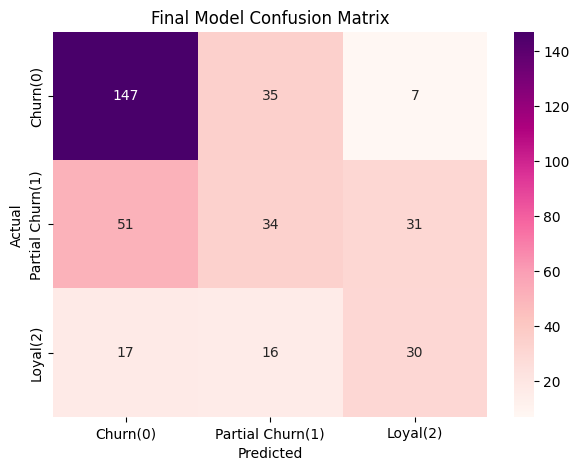

In [25]:
# 儲存格8 (LSTM訓練)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_simple_lstm(input_shape=(24, 7)):
    inputs = Input(shape=input_shape)
    x = LSTM(32, return_sequences=False)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

print("========== 開始訓練 LSTM 模型 ==========")
model_lstm = build_simple_lstm((24, 7))
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

model_lstm.fit(
    X_tr_scaled, y_tr_oh,
    validation_data=(X_val_scaled, y_val_oh),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

y_prob = model_lstm.predict(X_val_scaled)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_val_int
target_names = ['Churn(0)', 'Partial Churn(1)', 'Loyal(2)']

# 報表
print(classification_report(y_true, y_pred, target_names=target_names))

# 混淆矩陣
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Model Confusion Matrix')
plt.show()

In [15]:
#儲存格9
print("建立並訓練 CNN 模型...")

def build_cnn_model(input_shape=(24, 7)):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x) # 使用全局平均池化
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn_model((STEPS, FEATS))
cnn_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_history = cnn_model.fit(
    X_tr_scaled, y_tr_oh,
    validation_data=(X_val_scaled, y_val_oh),
    epochs=40,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[cnn_early_stop],
    verbose=0 # 設置為0以減少輸出
)

print("CNN 模型訓練完成。")

建立並訓練 CNN 模型...
CNN 模型訓練完成。


In [16]:
# 儲存格10 (傳統機器學習模型)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier # 新增 XGBoost 導入

print("========== 開始訓練傳統機器學習模型 ==========")

# 傳統模型通常需要二維特徵，所以我們將時序特徵展平
# 這裡重新切分資料，確保傳統模型有其獨立的訓練和驗證集
# 並對傳統模型的特徵進行縮放

# 使用原始的 X_train_pre 和 y_numeric
# 展平 X_train_pre (N, STEPS, FEATS) -> (N, STEPS * FEATS)
X_trad_flat = X_train_pre.reshape(X_train_pre.shape[0], -1)
y_trad_labels = y_numeric # 使用數值化標籤

# 切分傳統模型的訓練集和驗證集
X_trad_tr, X_trad_val, y_trad_tr, y_trad_val = train_test_split(
    X_trad_flat, y_trad_labels,
    test_size=0.2, random_state=42, stratify=y_trad_labels
)

# 標準化傳統模型的特徵
scaler_trad = StandardScaler()
X_trad_tr_scaled = scaler_trad.fit_transform(X_trad_tr)
X_trad_val_scaled = scaler_trad.transform(X_trad_val)

# 1. Logistic Regression
print("-> 訓練 Logistic Regression...")
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, class_weight=class_weight_dict)
log_reg_model.fit(X_trad_tr_scaled, y_trad_tr)
print("   Logistic Regression 訓練完成")

# 2. Decision Tree
print("-> 訓練 Decision Tree...")
dtree_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight_dict)
dtree_model.fit(X_trad_tr_scaled, y_trad_tr)
print("   Decision Tree 訓練完成")

# 3. Random Forest
print("-> 訓練 Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_trad_tr_scaled, y_trad_tr)
print("   Random Forest 訓練完成")

# 4. Support Vector Machine (使用較小的C以避免過擬合，並設定kernel='linear'或'rbf'，這裡用'linear'試試)
# 對於大型數據集，SVC可能訓練時間較長，通常會使用線性核或SGDClassifier
print("-> 訓練 Support Vector Machine (SVC)... (可能較耗時)")
svm_model = SVC(kernel='linear', random_state=42, probability=True, class_weight=class_weight_dict)
svm_model.fit(X_trad_tr_scaled, y_trad_tr)
print("   Support Vector Machine 訓練完成")

# 5. K-Nearest Neighbors
print("-> 訓練 K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5) # n_neighbors 可以調整
knn_model.fit(X_trad_tr_scaled, y_trad_tr)
print("   K-Nearest Neighbors 訓練完成")

# 6. XGBoost
print("-> 訓練 XGBoost...")
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    objective='multi:softprob',  # 輸出多分類的機率
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1,
    use_label_encoder=False # 避免未來版本警告
)
model_xgb.fit(X_trad_tr_scaled, y_trad_tr)
print("   XGBoost 訓練完成")

print("========== 所有傳統機器學習模型訓練完成 ==========")

========== 開始訓練傳統機器學習模型 ==========
-> 訓練 Logistic Regression...
   Logistic Regression 訓練完成
-> 訓練 Decision Tree...
   Decision Tree 訓練完成
-> 訓練 Random Forest...
   Random Forest 訓練完成
-> 訓練 Support Vector Machine (SVC)... (可能較耗時)
   Support Vector Machine 訓練完成
-> 訓練 K-Nearest Neighbors...
   K-Nearest Neighbors 訓練完成
-> 訓練 XGBoost...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [12:03:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   XGBoost 訓練完成
========== 所有傳統機器學習模型訓練完成 ==========


/tmp/ipykernel_1364/763554779.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_feature_importances.head(10), palette='viridis') # 顯示前10個重要特徵


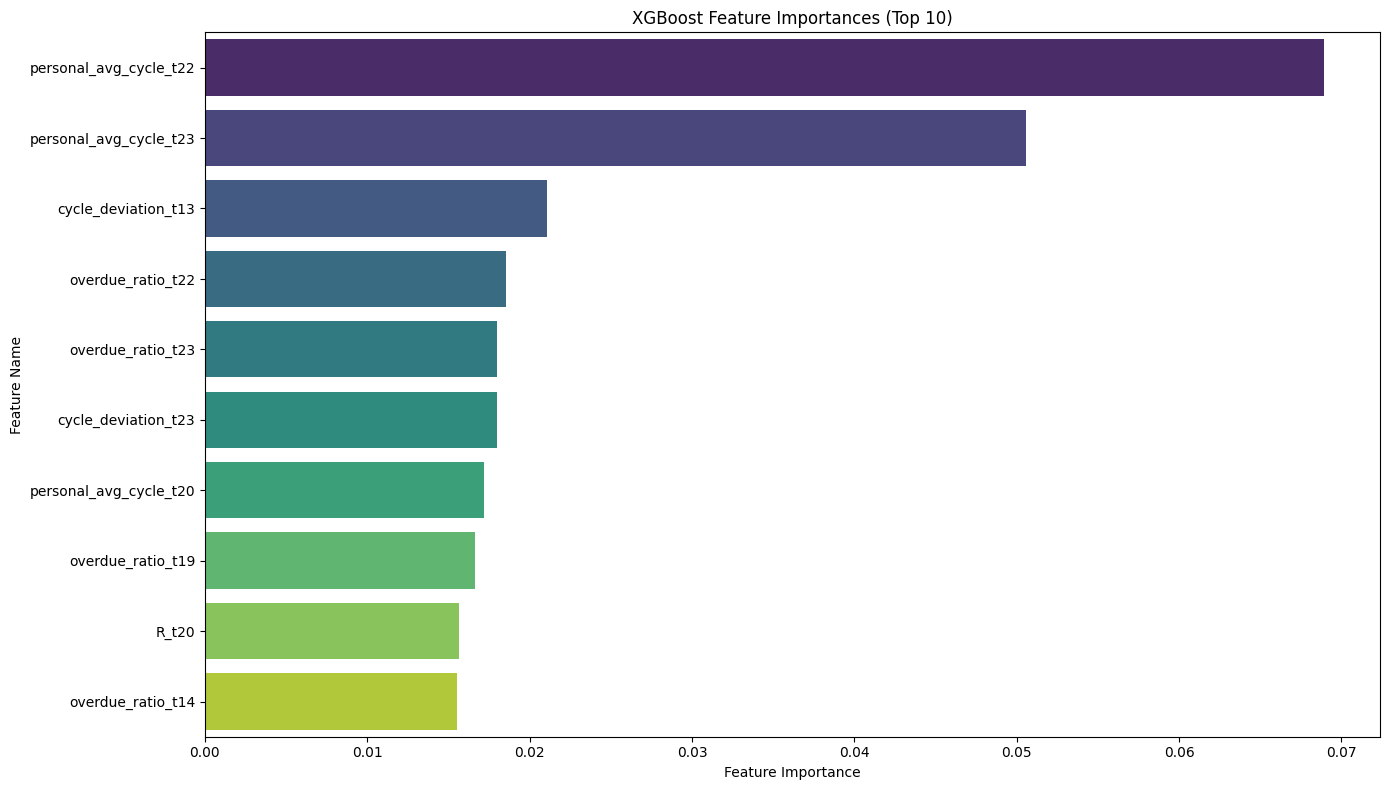

In [18]:
#儲存格10 特徵重要性視覺化(從XGboost提取重要性分數，列出前10重要的展平時序特徵)
import seaborn as sns

# --- 獲取特徵重要性 ---
# 確保 model_xgb 已被訓練
if 'model_xgb' in locals() and model_xgb:
    feature_importances = model_xgb.feature_importances_

    # 根據 X_tr_scaled 的形狀 (N, STEPS, FEATS) 重建特徵名稱
    # STEPS = 24, FEATS = 7
    original_feature_names = ['R', 'F', 'M', 'C', 'personal_avg_cycle', 'cycle_deviation', 'overdue_ratio']

    # 確保 STEPS 和 FEATS 已經定義，如果沒有則從 X_tr_scaled 推斷
    if 'STEPS' not in locals() or 'FEATS' not in locals():
        N_tr_temp, STEPS_temp, FEATS_temp = X_tr_scaled.shape
        STEPS = STEPS_temp
        FEATS = FEATS_temp

    feature_names = []
    for t in range(STEPS):
        for feature_name in original_feature_names:
            feature_names.append(f'{feature_name}_t{t}')

    # 創建 DataFrame 以便排序和繪圖
    df_feature_importances = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })

    # 依照重要性排序，取前N個重要的特徵，或全部顯示
    df_feature_importances = df_feature_importances.sort_values(by='Importance', ascending=False)

    # --- 繪製長條圖 ---
    plt.figure(figsize=(14, 8))
    sns.barplot(x='Importance', y='Feature', data=df_feature_importances.head(10), palette='viridis') # 顯示前10個重要特徵
    plt.title('XGBoost Feature Importances (Top 10)')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature Name')
    plt.tight_layout()
    plt.show()
else:
    print("Error: XGBoost model (model_xgb) not found or not trained. Please ensure 'mxBnZ4wQws85' cell is executed.")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

--- 所有模型 Macro F1-score 比較 ---
LSTM: 0.5080
CNN: 0.5103
Logistic Regression: 0.5043
Decision Tree: 0.4583
Random Forest: 0.4901
Support Vector Machine: 0.4672
K-Nearest Neighbors: 0.3911
XGBoost: 0.4619


/tmp/ipykernel_1364/1434474282.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names_f1, y=f1_values, palette='plasma')


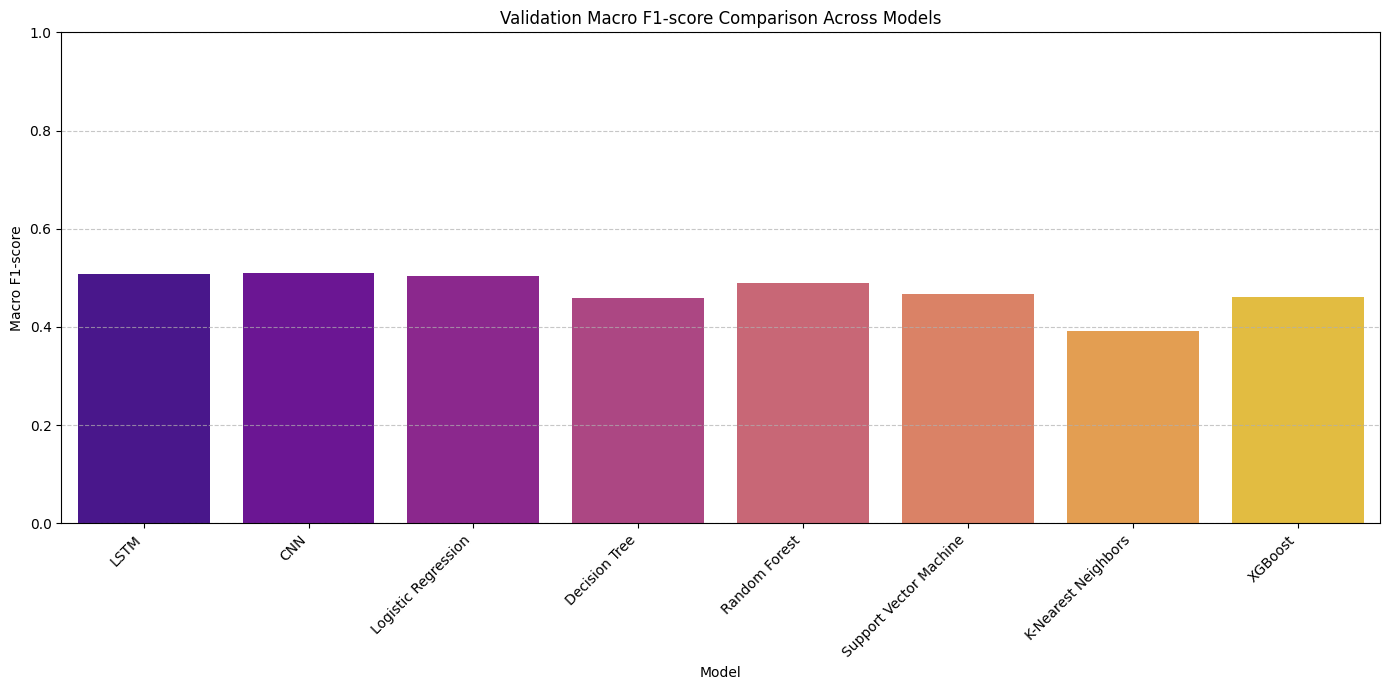

In [27]:
#儲存格11
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 深度學習模型 Macro F1-score ---
# LSTM with Attention Model
# 確保模型已定義且可預測
y_pred_main_model = np.argmax(model_lstm.predict(X_val_scaled), axis=1)
f1_main_model = f1_score(y_val_int, y_pred_main_model, average='macro')

# CNN Model
# 確保模型已定義且可預測
y_pred_cnn_model = np.argmax(cnn_model.predict(X_val_scaled), axis=1)
f1_cnn_model = f1_score(y_val_int, y_pred_cnn_model, average='macro')

# --- 傳統機器學習模型 Macro F1-score ---
# Logistic Regression
y_pred_log_reg = log_reg_model.predict(X_trad_val_scaled)
f1_log_reg = f1_score(y_trad_val, y_pred_log_reg, average='macro')

# Decision Tree
y_pred_dtree = dtree_model.predict(X_trad_val_scaled)
f1_dtree = f1_score(y_trad_val, y_pred_dtree, average='macro')

# Random Forest
y_pred_rf = rf_model.predict(X_trad_val_scaled)
f1_rf = f1_score(y_trad_val, y_pred_rf, average='macro')

# Support Vector Machine
y_pred_svm = svm_model.predict(X_trad_val_scaled)
f1_svm = f1_score(y_trad_val, y_pred_svm, average='macro')

# K-Nearest Neighbors
y_pred_knn = knn_model.predict(X_trad_val_scaled)
f1_knn = f1_score(y_trad_val, y_pred_knn, average='macro')

# XGBoost
y_pred_xgb = model_xgb.predict(X_trad_val_scaled)
f1_xgb = f1_score(y_trad_val, y_pred_xgb, average='macro')

# 收集所有模型的 Macro F1-score
model_f1_scores = {
    "LSTM": f1_main_model,
    "CNN": f1_cnn_model,
    "Logistic Regression": f1_log_reg,
    "Decision Tree": f1_dtree,
    "Random Forest": f1_rf,
    "Support Vector Machine": f1_svm,
    "K-Nearest Neighbors": f1_knn,
    "XGBoost": f1_xgb
}

print("\n--- 所有模型 Macro F1-score 比較 ---")
for model_name, f1 in model_f1_scores.items():
    print(f"{model_name}: {f1:.4f}")

# 可視化比較
model_names_f1 = list(model_f1_scores.keys())
f1_values = list(model_f1_scores.values())

plt.figure(figsize=(14, 7))
sns.barplot(x=model_names_f1, y=f1_values, palette='plasma')
plt.ylim(0, 1) # F1-score 範圍在 0 到 1 之間
plt.title('Validation Macro F1-score Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('Macro F1-score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

生成預測結果

In [34]:
# 儲存格12 (2023 結果輸出)
import pandas as pd
import numpy as np

# 1. 產生 2021-2022 的動態序列
print("正在產生 2021-2022 的行為序列...")
X_2023_raw, customer_ids_2023 = generate_dynamic_rfm_sequences(
    df_sales, df_calls, start_ym='2021-01', end_ym='2022-12'
)

# 2. 載入預測目標名單 final.xlsx
print("載入預測目標名單 final.xlsx...")
df_final_target = pd.read_excel('final.xlsx')
target_uids = df_final_target['新會員編號'].tolist()

# 3. 篩選出同時存在於歷史資料與 final.xlsx 中的會員
valid_indices = [i for i, uid in enumerate(customer_ids_2023) if uid in target_uids]
X_pred_subset = X_2023_raw[valid_indices]
uids_pred_subset = [customer_ids_2023[i] for i in valid_indices]

# 4. 預處理 X_pred_subset 得到 X_pred_pre
X_pred_pre = preprocess_X(X_pred_subset)


N_p, STEPS_p, FEATS_p = X_pred_pre.shape
X_pred_scaled = scaler.transform(X_pred_pre.reshape(-1, FEATS_p)).reshape(-1, STEPS_p, FEATS_p)
X_pred_flat = X_pred_scaled.reshape(N_p, -1)

# 建立基礎輸出 DataFrame，以 final.xlsx 的會員名單與順序為準
df_all_models_output = df_final_target.copy()

# 將 uids_pred_subset 合併到 df_all_models_output 中，確保預測結果只針對有數據的會員
# 否則 df_all_models_output 會包含 final.xlsx 所有會員，但 X_pred_flat 可能只有部分
df_all_models_output = df_all_models_output[df_all_models_output['新會員編號'].isin(uids_pred_subset)].copy()
df_all_models_output = df_all_models_output.set_index('新會員編號')
# 確保 df_all_models_output 的順序與 uids_pred_subset 一致，以正確匹配預測結果
df_all_models_output = df_all_models_output.loc[uids_pred_subset].reset_index()


# 數字標籤轉文字標籤的對照表
reverse_mapping = {0: 'churn', 1: 'partial churn', 2: 'loyal'}

# ==========================================
# 核心：8 大模型各自獨立預測 2023 類別
# ==========================================

# 1. LSTM with Attention
print("-> 正在預測: LSTM with Attention...")
prob_lstm = model_lstm.predict(X_pred_scaled) # 使用你最早訓練好的那個 model
class_lstm = np.argmax(prob_lstm, axis=1)
df_all_models_output['LSTM_with_Attention'] = [reverse_mapping[c] for c in class_lstm]

# 2. CNN Model
print("-> 正在預測: CNN Model...")
prob_cnn = cnn_model.predict(X_pred_scaled)
class_cnn = np.argmax(prob_cnn, axis=1)
df_all_models_output['CNN_Model'] = [reverse_mapping[c] for c in class_cnn]

# 3. Logistic Regression
print("-> 正在預測: Logistic Regression...")
# 修正預測 2023 應使用新資料的展平特徵：
class_lr = log_reg_model.predict(X_pred_flat)
df_all_models_output['Logistic_Regression'] = [reverse_mapping[c] for c in class_lr]

# 4. Decision Tree
print("-> 正在預測: Decision Tree...")
class_dt = dtree_model.predict(X_pred_flat)
df_all_models_output['Decision_Tree'] = [reverse_mapping[c] for c in class_dt]

# 5. Random Forest
print("-> 正在預測: Random Forest...")
class_rf = rf_model.predict(X_pred_flat)
df_all_models_output['Random_Forest'] = [reverse_mapping[c] for c in class_rf]

# 6. Support Vector Machine
print("-> 正在預測: Support Vector Machine...")
class_svm = svm_model.predict(X_pred_flat)
df_all_models_output['Support_Vector_Machine'] = [reverse_mapping[c] for c in class_svm]

# 7. K-Nearest Neighbors
print("-> 正在預測: K-Nearest Neighbors...")
class_knn = knn_model.predict(X_pred_flat)
df_all_models_output['K_Nearest_Neighbors'] = [reverse_mapping[c] for c in class_knn]

# 8. XGBoost
print("-> 正在預測: XGBoost...")
class_xgb = model_xgb.predict(X_pred_flat)
df_all_models_output['XGBoost'] = [reverse_mapping[c] for c in class_xgb]


# ==========================================
# 結果統計與輸出
# ==========================================

# 儲存到獨立的 Excel 檔案中
output_filename = 'each_model_predictions_2023.xlsx'
df_all_models_output.to_excel(output_filename, index=False)
print(f"\n 8 大模型各自預測結果已整合儲存至: {output_filename}")

# 統計各模型的預測類別分佈
print("\n 8 大模型預測結果分佈統計：")
model_cols = [
    'LSTM_with_Attention', 'CNN_Model', 'Logistic_Regression',
    'Decision_Tree', 'Random_Forest', 'Support Vector Machine',
    'K_Nearest_Neighbors', 'XGBoost'
]

# 建立對比表格
summary_list = []
for col in df_all_models_output.columns:
    # 確保只統計模型預測列
    if col in model_cols:
        counts = df_all_models_output[col].value_counts()
        summary_list.append({
            'Model': col,
            'Churn (Count)': counts.get('churn', 0),
            'Partial Churn (Count)': counts.get('partial churn', 0),
            'Loyal (Count)': counts.get('loyal', 0)
        })

df_summary = pd.DataFrame(summary_list)
print(df_summary.to_string(index=False))

正在產生 2021-2022 的行為序列...
特徵矩陣：(2608, 24, 7)  →  應為 (N, 24, 7)
載入預測目標名單 final.xlsx...
-> 正在預測: LSTM with Attention...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
-> 正在預測: CNN Model...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
-> 正在預測: Logistic Regression...
-> 正在預測: Decision Tree...
-> 正在預測: Random Forest...
-> 正在預測: Support Vector Machine...
-> 正在預測: K-Nearest Neighbors...
-> 正在預測: XGBoost...

 8 大模型各自預測結果已整合儲存至: each_model_predictions_2023.xlsx

 8 大模型預測結果分佈統計：
              Model  Churn (Count)  Partial Churn (Count)  Loyal (Count)
LSTM_with_Attention            301                     74            108
          CNN_Model            200                    129            154
Logistic_Regression            190                    106            187
      Decision_Tree            162                    250             71
      Random_Forest            241                    156             86
K_Nearest_Neighbors            314                     98             71
            XGBoost           